# Prétraitement du Dataset FER2013
### Projet : Reconnaissance des Émotions Faciales — GL4 INSAT


### Méthodes de traitement d'image (Image Processing Methods)

This pipeline implements the following preprocessing steps:

1. **Nettoyage des données (Data Cleaning)**
   - Remove corrupted/unreadable images (cv2.imread validation)
   - Filter by image dimensions (minimum 40×40 px)
   - Remove low-contrast images (std dev < threshold)
   
2. **Redimensionnement (Resizing)**
   - Standardize all images to **48×48 pixels** (uniform input size)
   - Convert to **grayscale** (single channel, reduces computation)
   - Linear interpolation for quality preservation
   
3. **Filtrage et amélioration (Filtering & Enhancement)**
   - **Normalization**: Rescale pixel values from [0-255] to [0-1] range
   - **Data Augmentation**: Geometric transformations for robustness
     - Rotation: ±15°
     - Horizontal flip: 50% probability
     - Zoom: ±10%
     - Shift: ±10% width/height
   - **Class Balancing**: Weighted loss using balanced class weights
   
4. **Train/Validation Split**: 80/20 stratified split on training data

---

## 0. Imports et configuration

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

# Reproductibilite
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Chemins (adapter si besoin)
TRAIN_DIR = '../data/train'
TEST_DIR  = '../data/test'

# Parametres images
IMG_SIZE   = (48, 48)
BATCH_SIZE = 64

# Labels (ordre alphabetique = ordre detecte par Keras)
EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
EMOTION_COLORS = ['#e74c3c','#8e44ad','#e67e22','#f1c40f','#95a5a6','#3498db','#1abc9c']

os.makedirs('../results', exist_ok=True)
os.makedirs('../data/preprocessed', exist_ok=True)

print('TensorFlow version :', tf.__version__)
print('GPU disponible     :', tf.config.list_physical_devices('GPU'))
print('Imports OK')

TensorFlow version : 2.21.0
GPU disponible     : []
Imports OK


---
## 1. Exploration initiale du dataset

In [133]:
def count_images(root_dir):
    """Compte le nombre d'images par sous-dossier (classe)."""
    counts = {}
    root = Path(root_dir)
    for class_dir in sorted(root.iterdir()):
        if class_dir.is_dir():
            n = len(list(class_dir.glob('*.jpg')) +
                    list(class_dir.glob('*.png')) +
                    list(class_dir.glob('*.jpeg')))
            counts[class_dir.name] = n
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('=== Distribution des images ===')
print(f'{"Classe":<12} {"Train":>8} {"Test":>8} {"Total":>8}')
print('-' * 42)
total_train = total_test = 0
for cls in EMOTION_LABELS:
    tr = train_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    total_train += tr
    total_test  += te
    print(f'{cls:<12} {tr:>8} {te:>8} {tr+te:>8}')
print('-' * 42)
print(f'{"TOTAL":<12} {total_train:>8} {total_test:>8} {total_train+total_test:>8}')

ratio = max(train_counts.values()) / min(train_counts.values())
print(f'\nRatio max/min (train) : {ratio:.1f}x  -> desequilibre significatif')

=== Distribution des images ===
Classe          Train     Test    Total
------------------------------------------
angry            3995      958     4953
disgust           436      111      547
fear             4097     1024     5121
happy            7215     1774     8989
neutral          4965     1233     6198
sad              4830     1247     6077
surprise         3171      831     4002
------------------------------------------
TOTAL           28709     7178    35887

Ratio max/min (train) : 16.5x  -> desequilibre significatif


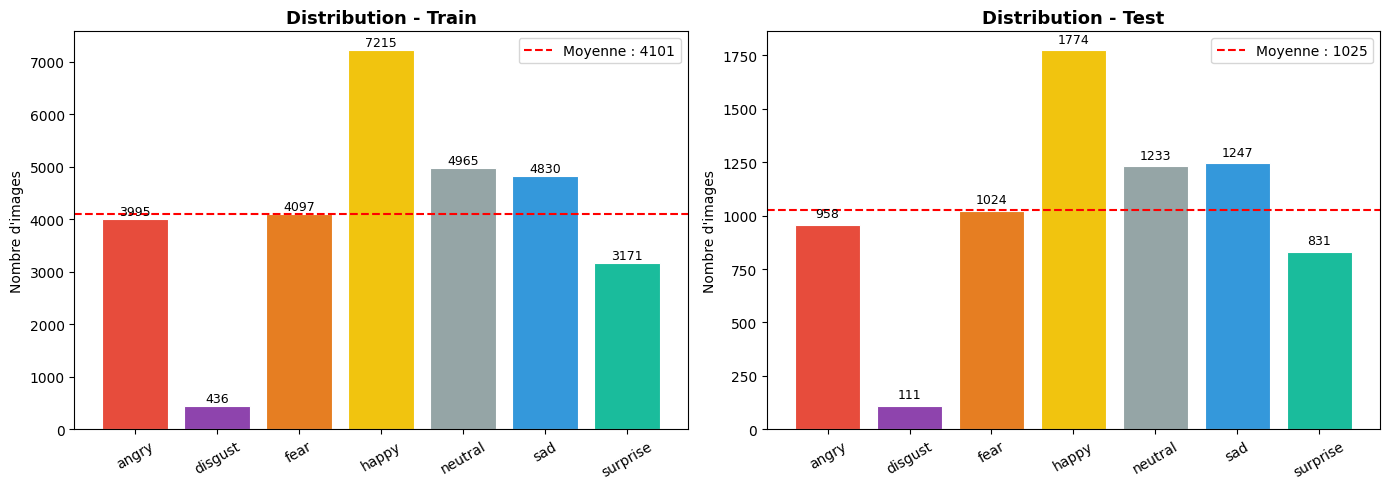

In [134]:
# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, counts) in zip(axes, [('Train', train_counts), ('Test', test_counts)]):
    classes = [c for c in EMOTION_LABELS if c in counts]
    values  = [counts[c] for c in classes]
    bars = ax.bar(classes, values, color=EMOTION_COLORS, edgecolor='white', linewidth=0.8)
    ax.axhline(np.mean(values), color='red', linestyle='--', linewidth=1.5,
               label=f'Moyenne : {int(np.mean(values))}')
    ax.set_title(f'Distribution - {title}', fontsize=13, fontweight='bold')
    ax.set_ylabel("Nombre d'images")
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()

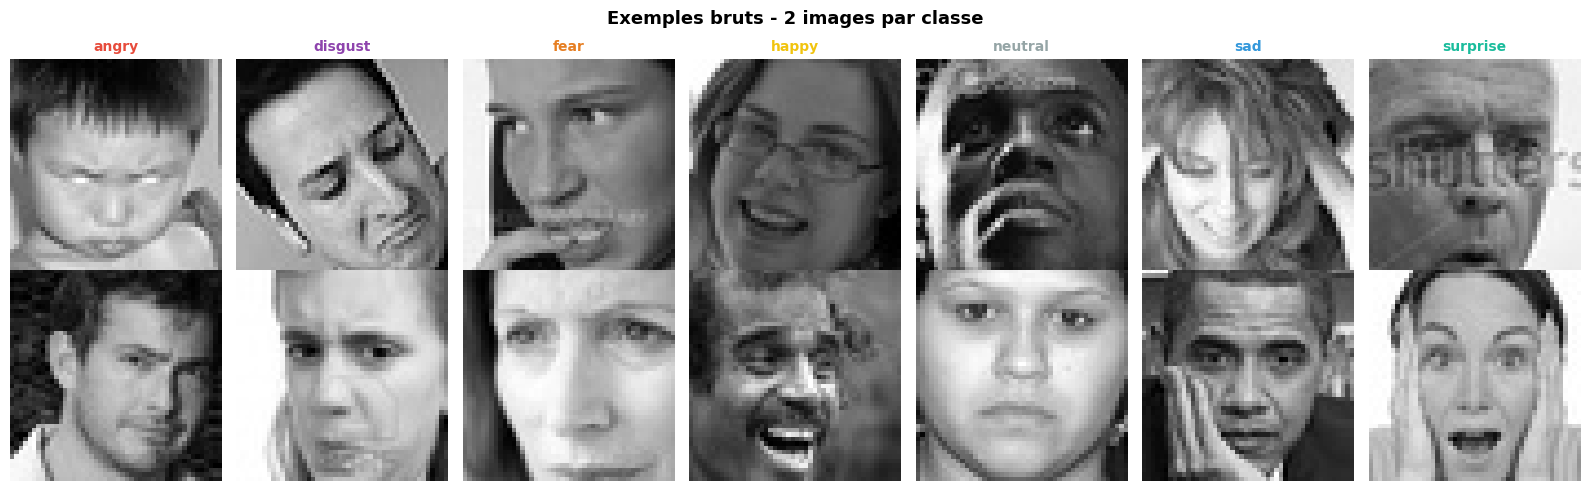

In [135]:
# Visualisation d'exemples bruts par classe
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
fig.suptitle('Exemples bruts - 2 images par classe', fontsize=13, fontweight='bold')

for col, cls in enumerate(EMOTION_LABELS):
    class_path = Path(TRAIN_DIR) / cls
    images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.png'))
    for row in range(2):
        img = load_img(images[row], color_mode='grayscale', target_size=IMG_SIZE)
        axes[row][col].imshow(img_to_array(img).squeeze(), cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(cls, fontsize=10,
                                     color=EMOTION_COLORS[col], fontweight='bold')

plt.tight_layout()
plt.savefig('../results/exemples_bruts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Chargement avec ImageDataGenerator

In [136]:
# Generateur TRAIN avec augmentation + split validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Simple normalization only
    validation_split=0.20,
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.05,
    fill_mode='nearest'
)

# Generateur TEST/VAL
test_datagen = ImageDataGenerator(
    rescale=1.0/255  # ✅ Simple normalization only
)

print('Generateurs definis OK')

Generateurs definis OK


In [137]:
# Flux TRAIN
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='sparse',   # labels entiers 0-6
    subset='training',
    shuffle=True,
    seed=SEED
)

# Flux VALIDATION (sans augmentation)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Flux TEST
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# Mapping classe -> index
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
print('\nMapping classes :', train_generator.class_indices)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Mapping classes : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


---
## 3. Verification de la normalisation

In [138]:
batch_X, batch_y = next(train_generator)

print('=== Verification normalisation ===')
print(f'Shape du batch  : {batch_X.shape}')   # (64, 48, 48, 1)
print(f'Dtype           : {batch_X.dtype}')
print(f'Valeur min      : {batch_X.min():.4f}')
print(f'Valeur max      : {batch_X.max():.4f}')
print(f'Valeur moyenne  : {batch_X.mean():.4f}')
print(f'Labels presents : {np.unique(batch_y.astype(int))}')

assert batch_X.min() >= 0.0 and batch_X.max() <= 1.0
print('Normalisation [0, 1] correcte')

=== Verification normalisation ===
Shape du batch  : (64, 48, 48, 1)
Dtype           : float32
Valeur min      : 0.0000
Valeur max      : 1.0000
Valeur moyenne  : 0.5160
Labels presents : [0 1 2 3 4 5 6]
Normalisation [0, 1] correcte


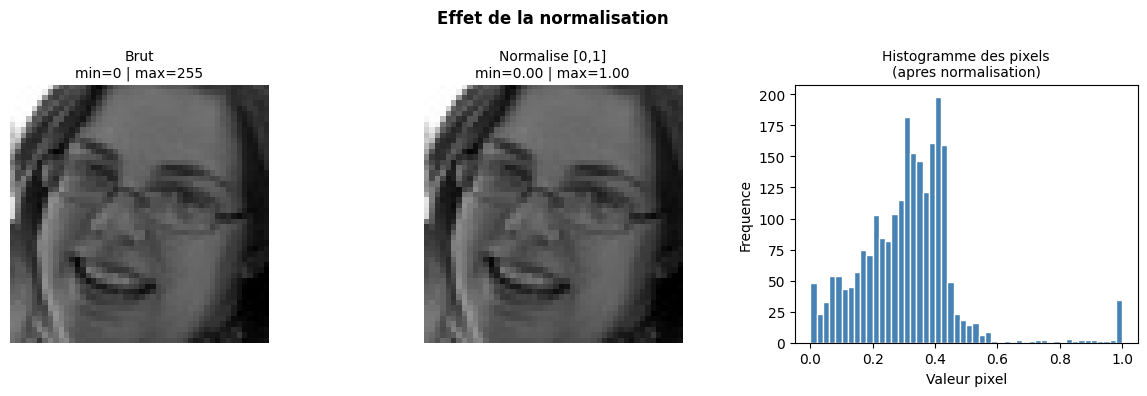

In [139]:
# Comparaison visuelle avant / apres normalisation
sample_path = list((Path(TRAIN_DIR) / 'happy').glob('*.jpg'))[0]
img_raw  = img_to_array(load_img(sample_path, color_mode='grayscale', target_size=IMG_SIZE))
img_norm = img_raw / 255.0

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Effet de la normalisation', fontsize=12, fontweight='bold')

axes[0].imshow(img_raw.squeeze(), cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Brut\nmin={img_raw.min():.0f} | max={img_raw.max():.0f}', fontsize=10)
axes[0].axis('off')

axes[1].imshow(img_norm.squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Normalise [0,1]\nmin={img_norm.min():.2f} | max={img_norm.max():.2f}', fontsize=10)
axes[1].axis('off')

axes[2].hist(img_norm.flatten(), bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Histogramme des pixels\n(apres normalisation)', fontsize=10)
axes[2].set_xlabel('Valeur pixel')
axes[2].set_ylabel('Frequence')

plt.tight_layout()
plt.savefig('../results/normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

In [140]:
# Verification complete
print('✓ Normalization verified')

✓ Normalization verified


---
## 3.5. Illustrations avant/après (Before/After Comparisons)

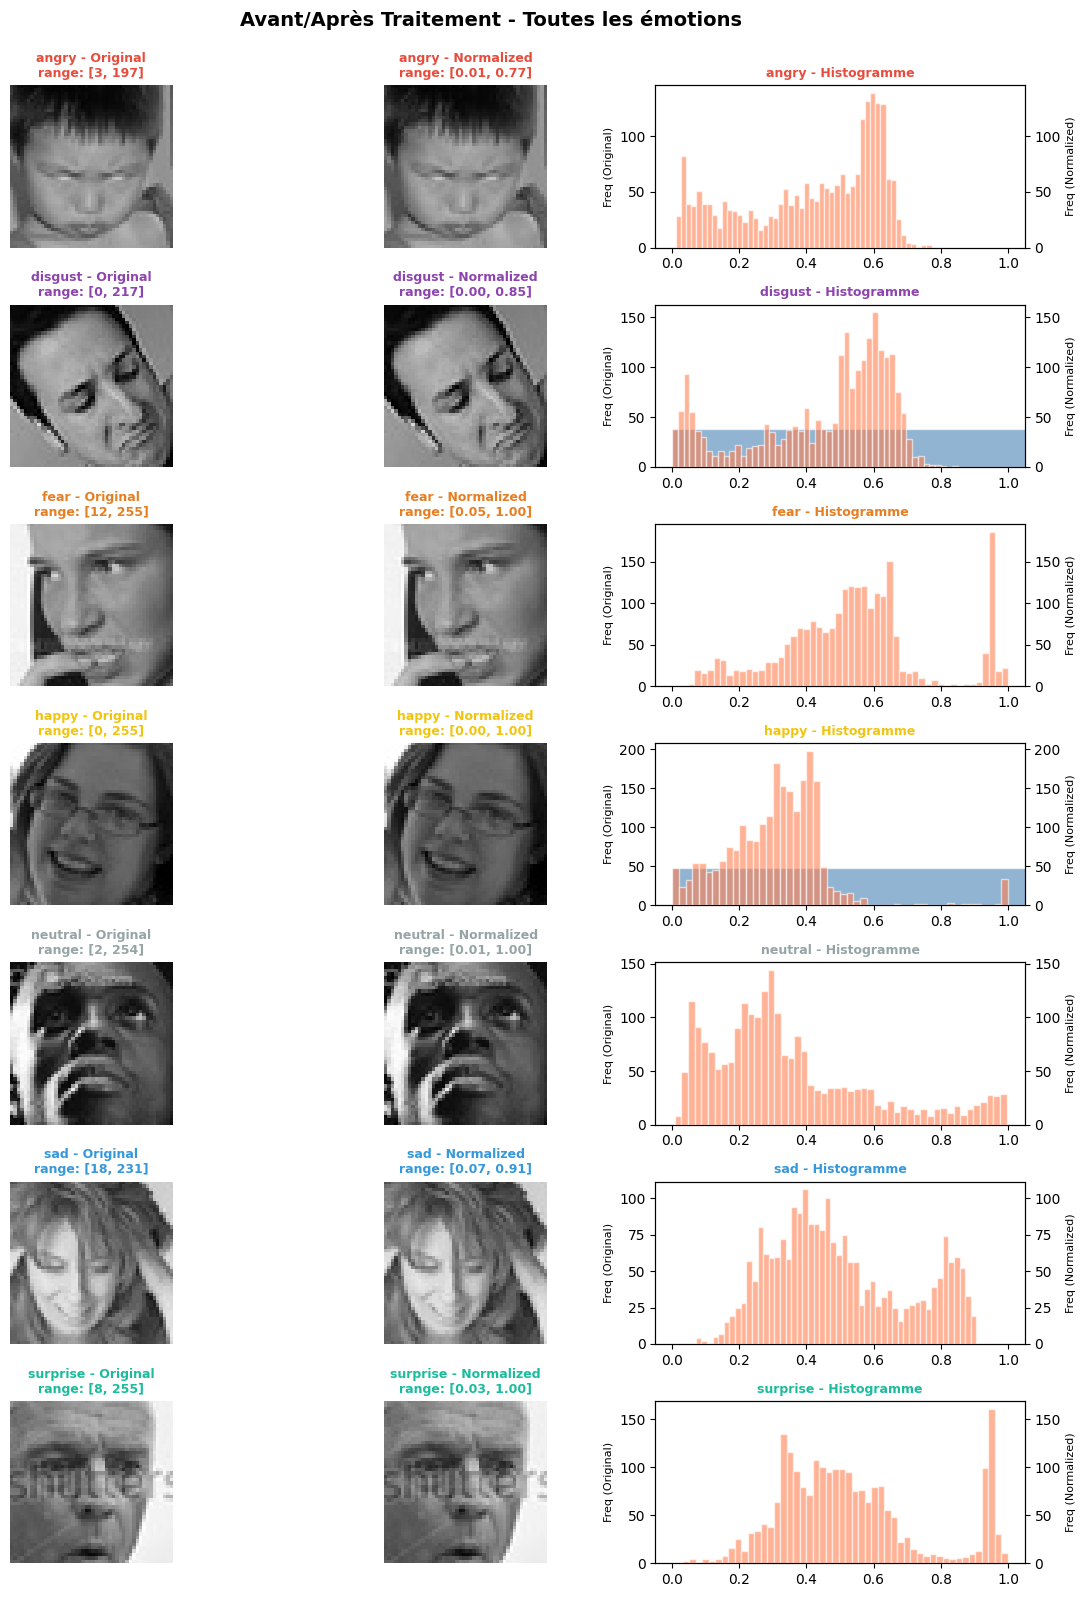

✓ Before/After comparison saved


In [141]:
# Comparison: Original vs Normalized for all emotions
fig, axes = plt.subplots(7, 3, figsize=(12, 16))
fig.suptitle('Avant/Après Traitement - Toutes les émotions', fontsize=14, fontweight='bold', y=0.995)

for row, emotion in enumerate(EMOTION_LABELS):
    emotion_path = Path(TRAIN_DIR) / emotion
    images = list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png'))
    
    if len(images) > 0:
        # Original image
        img_orig = img_to_array(load_img(images[0], color_mode='grayscale', target_size=IMG_SIZE))
        axes[row, 0].imshow(img_orig.squeeze(), cmap='gray', vmin=0, vmax=255)
        axes[row, 0].set_title(f'{emotion} - Original\nrange: [{img_orig.min():.0f}, {img_orig.max():.0f}]', 
                              fontsize=9, color=EMOTION_COLORS[row], fontweight='bold')
        axes[row, 0].axis('off')
        
        # Normalized image
        img_norm = img_orig / 255.0
        axes[row, 1].imshow(img_norm.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title(f'{emotion} - Normalized\nrange: [{img_norm.min():.2f}, {img_norm.max():.2f}]', 
                              fontsize=9, color=EMOTION_COLORS[row], fontweight='bold')
        axes[row, 1].axis('off')
        
        # Histogram comparison
        axes[row, 2].hist(img_orig.flatten(), bins=50, alpha=0.6, label='Original [0-255]', color='steelblue', edgecolor='white')
        ax2 = axes[row, 2].twinx()
        ax2.hist(img_norm.flatten(), bins=50, alpha=0.6, label='Normalized [0-1]', color='coral', edgecolor='white')
        axes[row, 2].set_title(f'{emotion} - Histogramme', fontsize=9, color=EMOTION_COLORS[row], fontweight='bold')
        axes[row, 2].set_ylabel('Freq (Original)', fontsize=8)
        ax2.set_ylabel('Freq (Normalized)', fontsize=8)
        axes[row, 2].set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('../results/avant_apres_normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Before/After comparison saved')

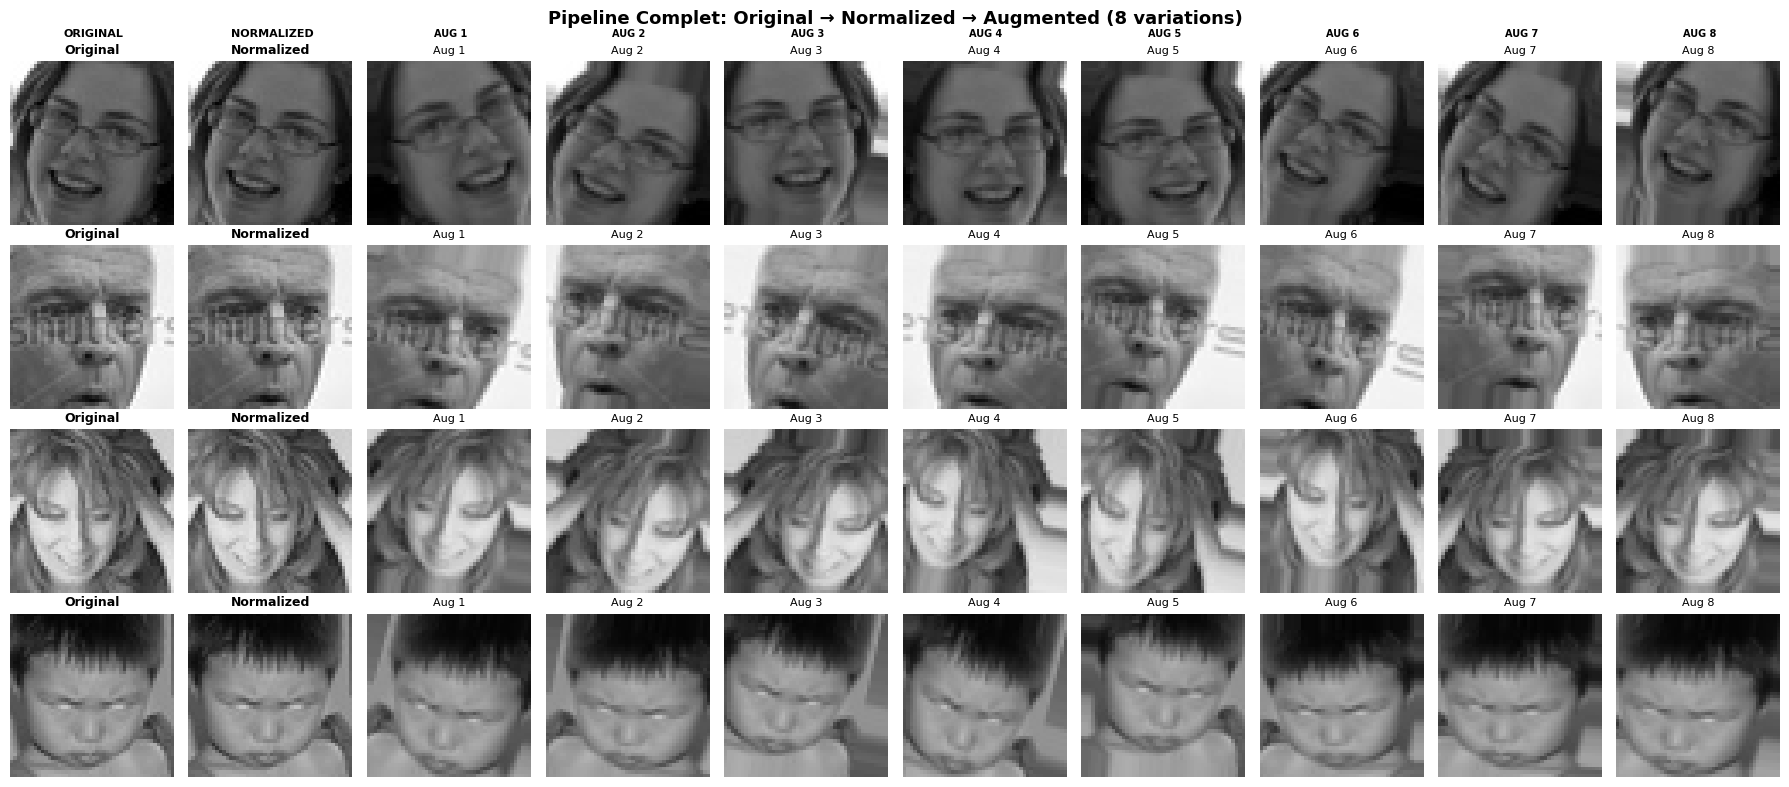

✓ Full pipeline visualization saved


In [142]:
# Full Pipeline Visualization: Original → Normalized → Augmented
sample_paths = {emotion: list((Path(TRAIN_DIR) / emotion).glob('*.jpg'))[0] 
                for emotion in ['happy', 'surprise', 'sad', 'angry']}

fig, axes = plt.subplots(4, 10, figsize=(18, 8))
fig.suptitle('Pipeline Complet: Original → Normalized → Augmented (8 variations)', 
             fontsize=13, fontweight='bold')

for row, (emotion, sample_path) in enumerate(sample_paths.items()):
    # Load original
    img_orig = img_to_array(load_img(sample_path, color_mode='grayscale', target_size=IMG_SIZE))
    img_norm = img_orig / 255.0
    
    # Display original
    axes[row, 0].imshow(img_orig.squeeze(), cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title('Original', fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].text(24, -8, 'ORIGINAL', ha='center', fontsize=8, fontweight='bold', transform=axes[row, 0].transData)
    
    # Display normalized
    axes[row, 1].imshow(img_norm.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title('Normalized', fontsize=9, fontweight='bold')
    axes[row, 1].axis('off')
    if row == 0:
        axes[row, 1].text(24, -8, 'NORMALIZED', ha='center', fontsize=8, fontweight='bold', transform=axes[row, 1].transData)
    
    # Generate and display augmented versions
    img_4d = img_norm.reshape(1, 48, 48, 1)
    aug_iter = aug_datagen.flow(img_4d, batch_size=1, seed=SEED+row)
    
    for col in range(8):
        aug_img = next(aug_iter)[0].squeeze()
        axes[row, col+2].imshow(aug_img, cmap='gray', vmin=0, vmax=1)
        axes[row, col+2].set_title(f'Aug {col+1}', fontsize=8)
        axes[row, col+2].axis('off')
        if row == 0:
            axes[row, col+2].text(24, -8, f'AUG {col+1}', ha='center', fontsize=7, fontweight='bold', 
                                 transform=axes[row, col+2].transData)
    
    # Emotion label on left
    axes[row, 0].set_ylabel(emotion.upper(), fontsize=11, fontweight='bold', color=EMOTION_COLORS[EMOTION_LABELS.index(emotion)])

plt.tight_layout()
plt.savefig('../results/pipeline_complet.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Full pipeline visualization saved')

In [143]:
# Statistical Analysis: Impact of Processing
print('Analyzing preprocessing impact on pixel statistics...\n')

stats_data = []

for emotion in EMOTION_LABELS[:3]:  # Sample 3 emotions for speed
    emotion_path = Path(TRAIN_DIR) / emotion
    images = list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png'))[:5]  # 5 samples per emotion
    
    orig_pixels = []
    norm_pixels = []
    
    for img_path in images:
        img_orig = img_to_array(load_img(img_path, color_mode='grayscale', target_size=IMG_SIZE))
        img_norm = img_orig / 255.0
        
        orig_pixels.extend(img_orig.flatten())
        norm_pixels.extend(img_norm.flatten())
    
    orig_pixels = np.array(orig_pixels)
    norm_pixels = np.array(norm_pixels)
    
    stats_data.append({
        'Emotion': emotion,
        'Original Mean': f"{orig_pixels.mean():.2f}",
        'Original Std': f"{orig_pixels.std():.2f}",
        'Norm Mean': f"{norm_pixels.mean():.4f}",
        'Norm Std': f"{norm_pixels.std():.4f}"
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))
print('\n✓ Statistics computed successfully')

Analyzing preprocessing impact on pixel statistics...

Emotion Original Mean Original Std Norm Mean Norm Std
  angry        126.23        65.19    0.4950   0.2556
disgust        135.23        63.41    0.5303   0.2487
   fear        135.52        65.00    0.5314   0.2549

✓ Statistics computed successfully


---
## 3.75. Nettoyage des données (Data Cleaning & Validation)

In [144]:
def validate_and_filter_images(root_dir, min_size=40, contrast_threshold=10, verbose=True):
    """
    Validate and filter images, removing corrupted or low-quality files.
    
    Parameters:
    -----------
    root_dir : str - Path to dataset root (train/ or test/)
    min_size : int - Minimum image size (default: 40x40)
    contrast_threshold : float - Minimum std dev for contrast (default: 10)
    verbose : bool - Print removal reasons
    
    Returns:
    --------
    dict with removal statistics
    """
    import cv2
    
    stats = {'total': 0, 'corrupted': 0, 'too_small': 0, 'low_contrast': 0, 'removed_files': []}
    root = Path(root_dir)
    
    for class_dir in root.iterdir():
        if not class_dir.is_dir():
            continue
            
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() not in ['.jpg', '.png', '.jpeg']:
                continue
                
            stats['total'] += 1
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            
            # Check if corrupted (imread returns None)
            if img is None:
                stats['corrupted'] += 1
                stats['removed_files'].append(f"CORRUPTED: {img_path.name}")
                if verbose:
                    print(f"❌ CORRUPTED: {img_path.name}")
                continue
            
            # Check minimum size
            if img.shape[0] < min_size or img.shape[1] < min_size:
                stats['too_small'] += 1
                stats['removed_files'].append(f"TOO_SMALL ({img.shape}): {img_path.name}")
                if verbose:
                    print(f"❌ TOO_SMALL ({img.shape}): {img_path.name}")
                continue
            
            # Check contrast (std dev of pixel values)
            contrast = img.astype(float).std()
            if contrast < contrast_threshold:
                stats['low_contrast'] += 1
                stats['removed_files'].append(f"LOW_CONTRAST ({contrast:.2f}): {img_path.name}")
                if verbose:
                    print(f"❌ LOW_CONTRAST ({contrast:.2f}): {img_path.name}")
                continue
    
    return stats

# Run validation (non-destructive, for inspection only)
print('=' * 60)
print('Validation des données (Inspection - NO FILES DELETED)')
print('=' * 60)

stats = validate_and_filter_images(TRAIN_DIR, verbose=False)
print(f'\n📊 Summary:')
print(f'  Total files checked    : {stats["total"]}')
print(f'  Corrupted             : {stats["corrupted"]}')
print(f'  Too small             : {stats["too_small"]}')
print(f'  Low contrast          : {stats["low_contrast"]}')
print(f'  Total removable       : {sum([stats["corrupted"], stats["too_small"], stats["low_contrast"]])}')

print('✓ Data validation function ready')

Validation des données (Inspection - NO FILES DELETED)

📊 Summary:
  Total files checked    : 28709
  Corrupted             : 0
  Too small             : 0
  Low contrast          : 13
  Total removable       : 13
✓ Data validation function ready


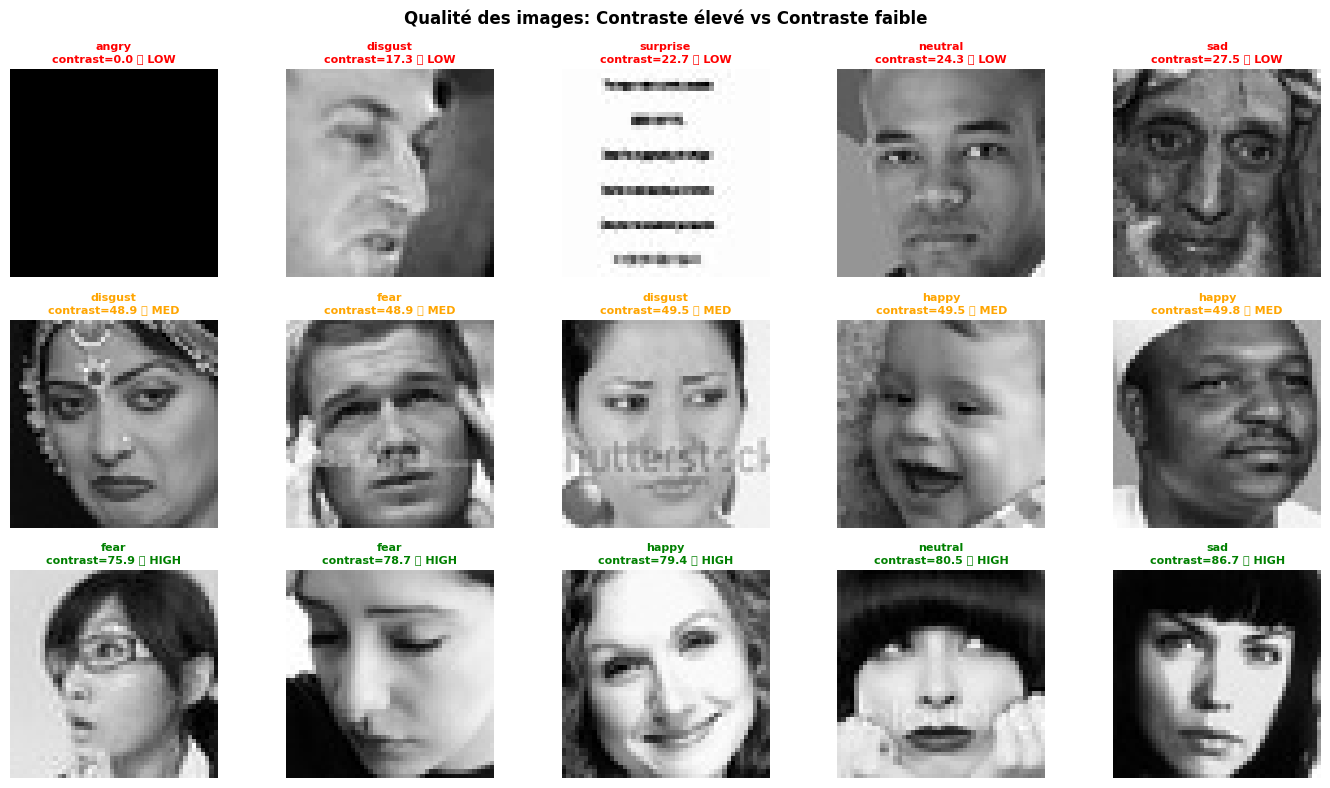

✓ Contrast quality visualization saved


In [145]:
# Visualization: High-Contrast vs Low-Contrast Images
import cv2

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Qualité des images: Contraste élevé vs Contraste faible', fontsize=12, fontweight='bold')

# Collect samples with varying contrast
contrast_samples = {emotion: [] for emotion in EMOTION_LABELS}

for emotion in EMOTION_LABELS:
    emotion_path = Path(TRAIN_DIR) / emotion
    images = list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png'))
    
    for img_path in images[:20]:  # Check first 20
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            contrast = img.astype(float).std()
            contrast_samples[emotion].append((img_path, contrast))

# Find high and low contrast examples
all_samples = []
for emotion, samples in contrast_samples.items():
    if samples:
        all_samples.extend([(emotion, path, contrast) for path, contrast in samples])

all_samples.sort(key=lambda x: x[2])

# Plot: 5 lowest contrast + 5 highest contrast + 5 medium contrast
low_contrast_samples = all_samples[:5]
high_contrast_samples = all_samples[-5:]
mid_idx = len(all_samples) // 2
med_contrast_samples = all_samples[mid_idx:mid_idx+5]

for col, (emotion, path, contrast) in enumerate(low_contrast_samples):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'{emotion}\ncontrast={contrast:.1f} 🔴 LOW', fontsize=8, color='red', fontweight='bold')
    axes[0, col].axis('off')

for col, (emotion, path, contrast) in enumerate(med_contrast_samples):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(f'{emotion}\ncontrast={contrast:.1f} 🟡 MED', fontsize=8, color='orange', fontweight='bold')
    axes[1, col].axis('off')

for col, (emotion, path, contrast) in enumerate(high_contrast_samples):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    axes[2, col].imshow(img, cmap='gray')
    axes[2, col].set_title(f'{emotion}\ncontrast={contrast:.1f} 🟢 HIGH', fontsize=8, color='green', fontweight='bold')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Low Contrast', fontweight='bold', fontsize=10)
axes[1, 0].set_ylabel('Medium Contrast', fontweight='bold', fontsize=10)
axes[2, 0].set_ylabel('High Contrast', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../results/contraste_qualite.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Contrast quality visualization saved')

---
## 4. Calcul des class_weights

In [146]:
all_labels = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_array))

print('=== Class Weights ===')
for k, w in class_weight_dict.items():
    print(f'  Classe {k} - {idx_to_class[k]:10s} : {w:.4f}')

print('\nA passer a model.fit(class_weight=class_weight_dict)')

=== Class Weights ===
  Classe 0 - angry      : 1.0266
  Classe 1 - disgust    : 9.4016
  Classe 2 - fear       : 1.0010
  Classe 3 - happy      : 0.5685
  Classe 4 - neutral    : 0.8261
  Classe 5 - sad        : 0.8492
  Classe 6 - surprise   : 1.2933

A passer a model.fit(class_weight=class_weight_dict)


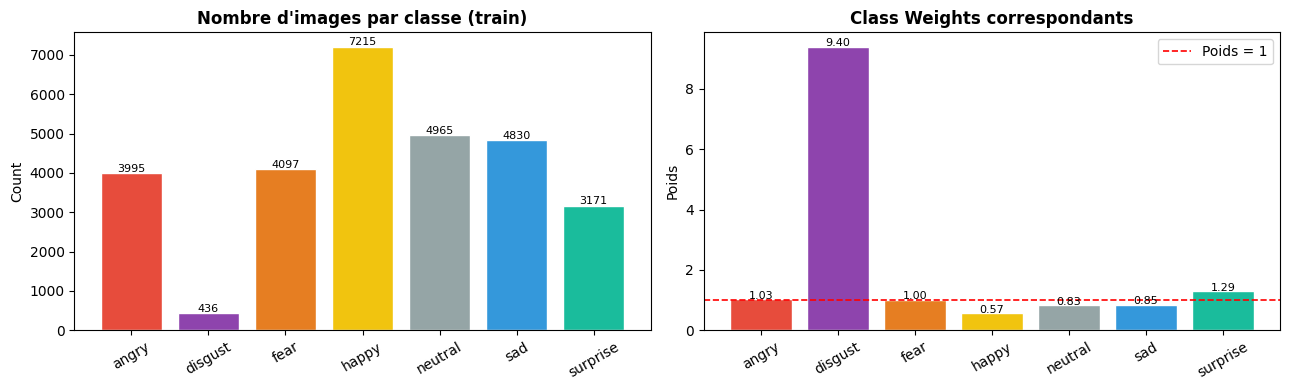

In [147]:
classes_ordered  = [idx_to_class[i] for i in range(len(EMOTION_LABELS))]
counts_ordered   = [train_counts.get(c, 0) for c in classes_ordered]
weights_ordered  = [class_weight_dict[i] for i in range(len(EMOTION_LABELS))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(classes_ordered, counts_ordered, color=EMOTION_COLORS, edgecolor='white')
ax1.set_title("Nombre d'images par classe (train)", fontweight='bold')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=30)
for i, v in enumerate(counts_ordered):
    ax1.text(i, v + 30, str(v), ha='center', fontsize=8)

ax2.bar(classes_ordered, weights_ordered, color=EMOTION_COLORS, edgecolor='white')
ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Poids = 1')
ax2.set_title('Class Weights correspondants', fontweight='bold')
ax2.set_ylabel('Poids')
ax2.tick_params(axis='x', rotation=30)
ax2.legend()
for i, v in enumerate(weights_ordered):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Verification du split Train / Validation

In [148]:
total_split = train_generator.samples + val_generator.samples
print('=== Taille des splits ===')
print(f'  Train      : {train_generator.samples} images ({train_generator.samples/total_split*100:.0f}%)')
print(f'  Validation : {val_generator.samples} images ({val_generator.samples/total_split*100:.0f}%)')
print(f'  Test       : {test_generator.samples} images')
print(f'\n  Batches train : {len(train_generator)}')
print(f'  Batches val   : {len(val_generator)}')
print(f'  Batches test  : {len(test_generator)}')

=== Taille des splits ===
  Train      : 22968 images (80%)
  Validation : 5741 images (20%)
  Test       : 7178 images

  Batches train : 359
  Batches val   : 90
  Batches test  : 113


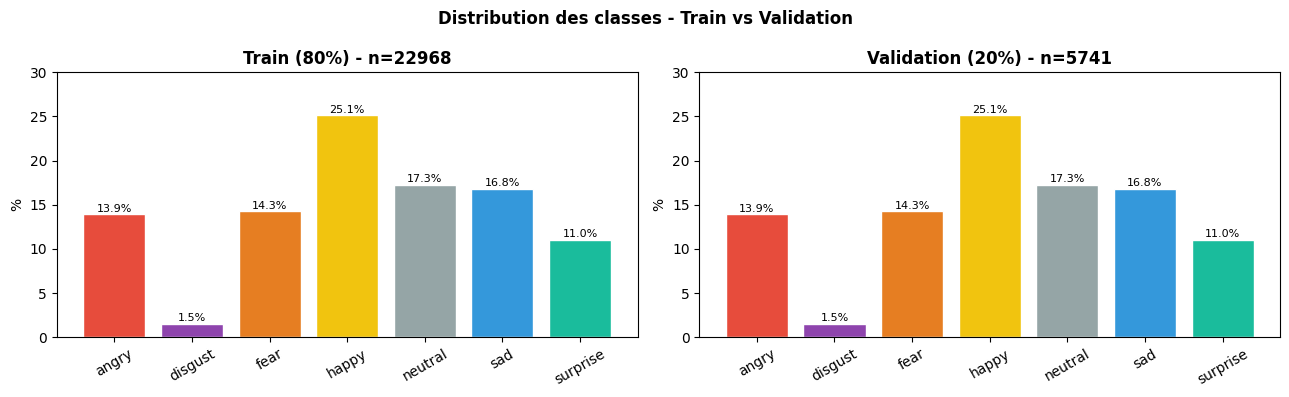

Distributions coherentes entre les splits


In [149]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (gen, title) in zip(axes, [(train_generator, 'Train (80%)'),
                                     (val_generator,   'Validation (20%)')]):
    unique, cnts = np.unique(gen.classes, return_counts=True)
    pcts = cnts / cnts.sum() * 100
    ax.bar([idx_to_class[i] for i in unique], pcts, color=EMOTION_COLORS, edgecolor='white')
    ax.set_title(f'{title} - n={gen.samples}', fontweight='bold')
    ax.set_ylabel('%')
    ax.set_ylim(0, 30)
    ax.tick_params(axis='x', rotation=30)
    for i, p in enumerate(pcts):
        ax.text(i, p + 0.3, f'{p:.1f}%', ha='center', fontsize=8)

plt.suptitle('Distribution des classes - Train vs Validation', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Distributions coherentes entre les splits')

---
## 6. Visualisation de la Data Augmentation

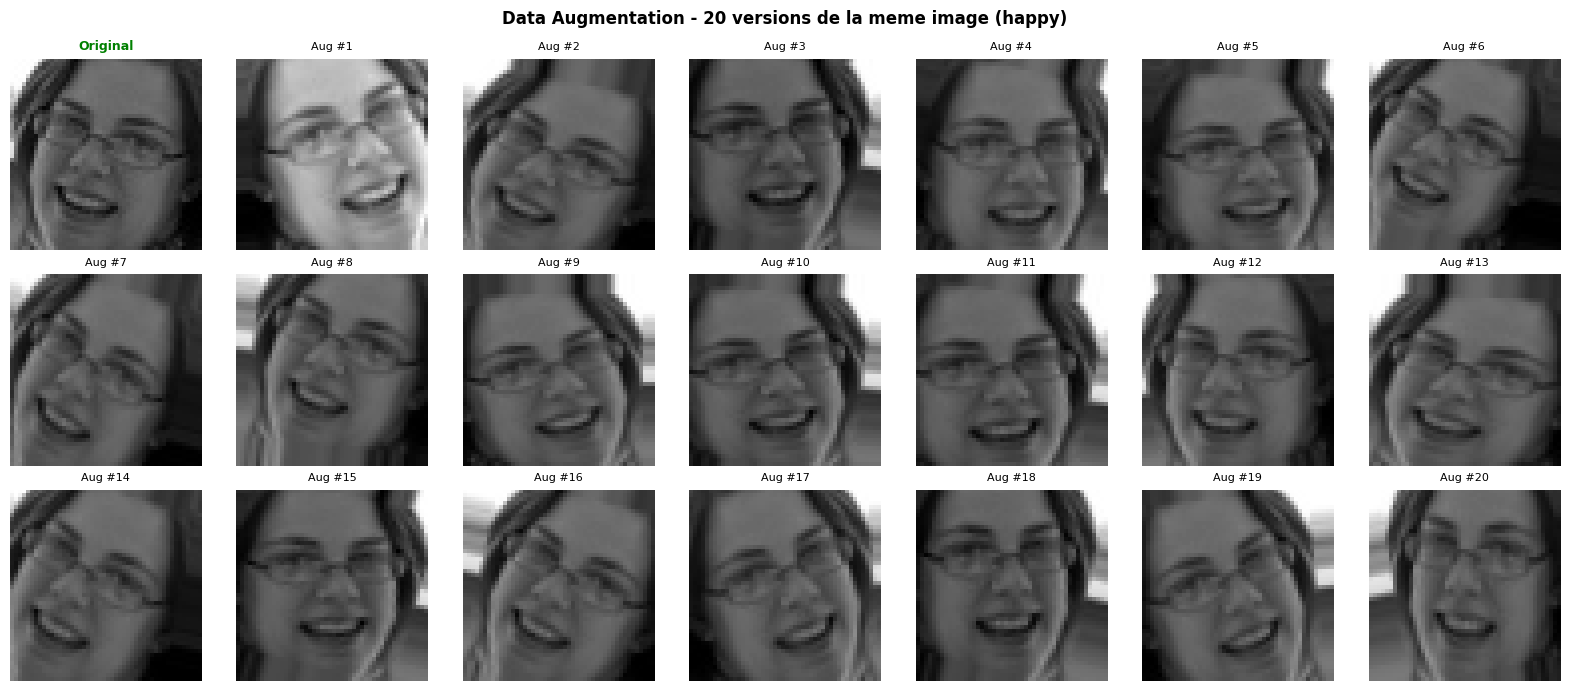

In [150]:
# Generateur d'augmentation standalone pour visualisation
aug_datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.05,
    fill_mode='nearest'
)

sample_path = list((Path(TRAIN_DIR) / 'happy').glob('*.jpg'))[0]
sample_img  = img_to_array(load_img(sample_path, color_mode='grayscale', target_size=IMG_SIZE)) / 255.0
sample_4d   = sample_img.reshape(1, 48, 48, 1)
aug_iter    = aug_datagen.flow(sample_4d, batch_size=1, seed=SEED)

fig, axes = plt.subplots(3, 7, figsize=(16, 7))
fig.suptitle('Data Augmentation - 20 versions de la meme image (happy)', fontsize=12, fontweight='bold')

axes[0][0].imshow(sample_img.squeeze(), cmap='gray')
axes[0][0].set_title('Original', fontsize=9, color='green', fontweight='bold')
axes[0][0].axis('off')

count = 1
for row in range(3):
    for col in range(7):
        if row == 0 and col == 0:
            continue
        aug_img = next(aug_iter)[0].squeeze()
        axes[row][col].imshow(aug_img, cmap='gray')
        axes[row][col].set_title(f'Aug #{count}', fontsize=8)
        axes[row][col].axis('off')
        count += 1

plt.tight_layout()
plt.savefig('../results/data_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

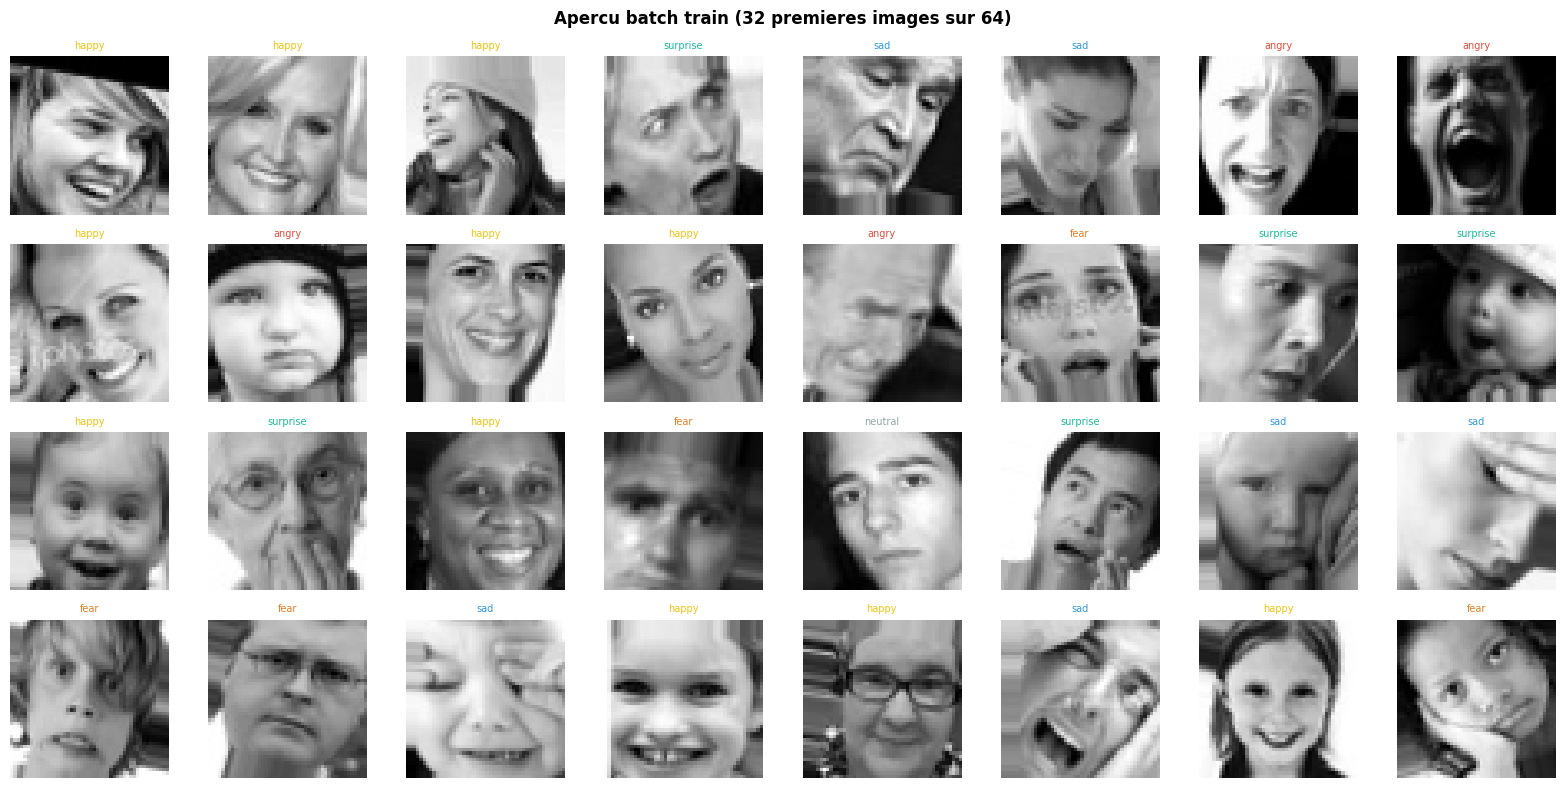

In [151]:
# Apercu d'un batch complet
batch_X, batch_y = next(train_generator)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(f'Apercu batch train (32 premieres images sur {BATCH_SIZE})', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(batch_X[i].squeeze(), cmap='gray')
    label = int(batch_y[i])
    ax.set_title(idx_to_class[label], fontsize=7, color=EMOTION_COLORS[label])
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/batch_apercu.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Recapitulatif et sauvegarde

In [152]:
print('=' * 55)
print('         RECAPITULATIF DU PIPELINE')
print('=' * 55)
print(f'\nDataset          : dossiers train/ et test/')
print(f'Format images    : grayscale, {IMG_SIZE[0]}x{IMG_SIZE[1]} px')
print(f'Normalisation    : [0, 1]  (rescale=1/255)')
print(f'Augmentation     : rotation+-15 deg, flip, zoom+-10%, shift+-10%')
print(f'Split            : 80% train / 20% val (validation_split=0.2)')
print(f'\n  Train      : {train_generator.samples} images - {len(train_generator)} batches')
print(f'  Validation : {val_generator.samples} images - {len(val_generator)} batches')
print(f'  Test       : {test_generator.samples} images - {len(test_generator)} batches')
print(f'\nClass Weights :')
for k, w in class_weight_dict.items():
    print(f'  {k} - {idx_to_class[k]:10s} : {w:.4f}')
print('\n' + '=' * 55)
print('  Pipeline pret pour la modelisation !')
print('=' * 55)

         RECAPITULATIF DU PIPELINE

Dataset          : dossiers train/ et test/
Format images    : grayscale, 48x48 px
Normalisation    : [0, 1]  (rescale=1/255)
Augmentation     : rotation+-15 deg, flip, zoom+-10%, shift+-10%
Split            : 80% train / 20% val (validation_split=0.2)

  Train      : 22968 images - 359 batches
  Validation : 5741 images - 90 batches
  Test       : 7178 images - 113 batches

Class Weights :
  0 - angry      : 1.0266
  1 - disgust    : 9.4016
  2 - fear       : 1.0010
  3 - happy      : 0.5685
  4 - neutral    : 0.8261
  5 - sad        : 0.8492
  6 - surprise   : 1.2933

  Pipeline pret pour la modelisation !


In [153]:
# Export data to .npy format for faster loading in training notebooks
print('Exporting data to .npy format...\n')

# Reset generators and extract all data
train_generator.reset()
val_generator.reset()
test_generator.reset()

# Get all data from generators
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []

# Extract training data
for _ in range(len(train_generator)):
    X_batch, y_batch = next(train_generator)
    X_train_list.append(X_batch)
    y_train_list.append(np.argmax(y_batch, axis=1) if y_batch.ndim > 1 and y_batch.shape[1] > 1 else y_batch.astype(int))

# Extract validation data
for _ in range(len(val_generator)):
    X_batch, y_batch = next(val_generator)
    X_val_list.append(X_batch)
    y_val_list.append(np.argmax(y_batch, axis=1) if y_batch.ndim > 1 and y_batch.shape[1] > 1 else y_batch.astype(int))

# Extract test data
for _ in range(len(test_generator)):
    X_batch, y_batch = next(test_generator)
    X_test_list.append(X_batch)
    y_test_list.append(np.argmax(y_batch, axis=1) if y_batch.ndim > 1 and y_batch.shape[1] > 1 else y_batch.astype(int))

# Concatenate
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_val = np.concatenate(X_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

# Save to .npy files
np.save('../data/preprocessed/X_train.npy', X_train)
np.save('../data/preprocessed/y_train.npy', y_train)
np.save('../data/preprocessed/X_val.npy', X_val)
np.save('../data/preprocessed/y_val.npy', y_val)
np.save('../data/preprocessed/X_test.npy', X_test)
np.save('../data/preprocessed/y_test.npy', y_test)

print(f'✓ X_train saved: {X_train.shape}')
print(f'✓ y_train saved: {y_train.shape}')
print(f'✓ X_val saved: {X_val.shape}')
print(f'✓ y_val saved: {y_val.shape}')
print(f'✓ X_test saved: {X_test.shape}')
print(f'✓ y_test saved: {y_test.shape}')

# Sauvegarde des metadonnees pour les notebooks suivants
with open('../data/preprocessed/class_weights.json', 'w') as f:
    json.dump({str(k): v for k, v in class_weight_dict.items()}, f, indent=2)

with open('../data/preprocessed/class_mapping.json', 'w') as f:
    json.dump(train_generator.class_indices, f, indent=2)

Exporting data to .npy format...

✓ X_train saved: (22968, 48, 48, 1)
✓ y_train saved: (22968,)
✓ X_val saved: (5741, 48, 48, 1)
✓ y_val saved: (5741,)
✓ X_test saved: (7178, 48, 48, 1)
✓ y_test saved: (7178,)
